# Modelos de ensamble

Ya se ha visto que los árboles de decisión son modelos que funcionan muy bien, en general mejor que los modelos lineales, y tienen varias ventajas como:
- Son fácilmente interpretables.
- Con ellos no es necesario hacer preprocesamientos complejos, porque son no paramétricos, es decir, no hacen supuestos sobre las distribuciones de los datos.
- Gestionan de manera natural los datos nulos o faltantes, tampoco es necesario hacer eliminación o imputación previa de datos nulos.

Sin embargo, los árboles de decisión tienen 2 problemas importantes:
- Son muy inestables: pequeños cambios en los datos pueden llevar a cambios drásticos en el modelo.
- Tienden a sobreajustarse muy fácilmente.

Estos problemas pueden ser resueltos trabajando con muchos árboles simultáneamente. Estos modelos que trabajan con muchos árboles se conocen como modelos de ensamble.

In [ ]:
import pandas as pd

cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']

df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data',
    sep=r'\s+',
    header=None,
    na_values='?',
    names=cols
    )

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


Para tener un punto de comparación, se van a entrenar 2 modelos de regresión, uno lineal y uno de árbol.

## Modelo lineal

In [ ]:
from sklearn.model_selection import train_test_split

df_dropna = df.dropna()
X = df_dropna.drop(columns=['mpg', 'car name'])
y = df_dropna['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    )

print('Train:', X_train.shape, y_train.shape)
print('Test:',  X_test.shape, y_test.shape)

Train: (313, 7) (313,)
Test: (79, 7) (79,)


In [ ]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PolynomialFeatures
)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

num_vars = ['displacement', 'horsepower', 'weight', 'acceleration'] # Se definen las variables numéricas
oe_cyl = OrdinalEncoder(categories=[[3., 4., 5., 6., 8.]])
oe_my = OrdinalEncoder(categories=[[70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82.]])
ss = StandardScaler()
poly = PolynomialFeatures(degree=2, include_bias=False)
num_process = Pipeline([('ss', ss), ('poly', poly)])

preprocessor = ColumnTransformer(
    transformers=[('oe_cyl', oe_cyl, ['cylinders']), # Codificación ordinal para la variable 'cylinders'
                  ('oe_my', oe_my, ['model year']), # Codificación ordinal para la variable 'model_year'
                  ('num_process', num_process, num_vars)], # Prepocesamiento de las variables numéricas
                  remainder='passthrough') # El resto de las columnas se mantienen sin cambios

model = Ridge(
    max_iter = 10000,
    solver = 'saga',
    random_state=1
    ) # Se define el modelo

pipe = Pipeline(
    [('preprocessor', preprocessor),
     ('model', model)]
    ) # Se define un pipeline con el preprocesador y el modelo Ridge

grid = {'model__alpha':np.logspace(-3, 3, 20)}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    scoring='neg_root_mean_squared_error',
    )

grid_search.fit(X_train, y_train)

print(f'Best validation score: {-grid_search.best_score_:.3f} with alpha: {grid_search.best_params_}')
print(f'Train score: {-grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {-grid_search.score(X_test, y_test):.3f}')

Best validation score: 2.968 with alpha: {'model__alpha': np.float64(6.158482110660261)}
Train score: 2.757
Test score: 3.079


In [ ]:
best_model = grid_search.best_estimator_

pesos = pd.DataFrame(
    data = best_model.named_steps['model'].coef_, # Se extraen los coeficientes del modelo Ridge  # noqa: E501
    index = best_model.named_steps['preprocessor'].get_feature_names_out().tolist(), # Se extraen los nombres de las variables  # noqa: E501
    columns=['Coeficiente']
    )

pesos.loc['intercepto'] = best_model.named_steps['model'].intercept_ # Se extrae el intercepto del modelo Ridge  # noqa: E501
pesos.sort_values(by='Coeficiente', ascending=False)

,Coeficiente
intercepto,15.128168
num_process__displacement horsepower,1.071525
oe_my__model year,0.757236
remainder__origin,0.736164
num_process__weight^2,0.575706
num_process__weight acceleration,0.387932
num_process__displacement weight,0.353337
num_process__horsepower acceleration,0.344773
num_process__acceleration^2,0.321184
num_process__horsepower weight,0.315843


## Árbol de decisión

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['mpg', 'car name'])
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
    )

print('Train:', X_train.shape, y_train.shape)
print('Test:',  X_test.shape, y_test.shape)

Train: (318, 7) (318,)
Test: (80, 7) (80,)


In [ ]:
from sklearn.tree import DecisionTreeRegressor

grid = {
    'max_depth':range(1, 10),
    'min_samples_leaf': range(1, 10)
}

grid_search = GridSearchCV(
    estimator = DecisionTreeRegressor(random_state=1),
    param_grid = grid,
    scoring = 'neg_root_mean_squared_error'
    )

grid_search.fit(X_train, y_train)

print(f'Best validation score: {-grid_search.best_score_:.3f} with parameters: {grid_search.best_params_}')
print(f'Train score: {-grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {-grid_search.score(X_test, y_test):.3f}')

Best validation score: 3.459 with parameters: {'max_depth': 7, 'min_samples_leaf': 4}
Train score: 1.963
Test score: 3.442


Estos serían los 3 primeros niveles del árbol:

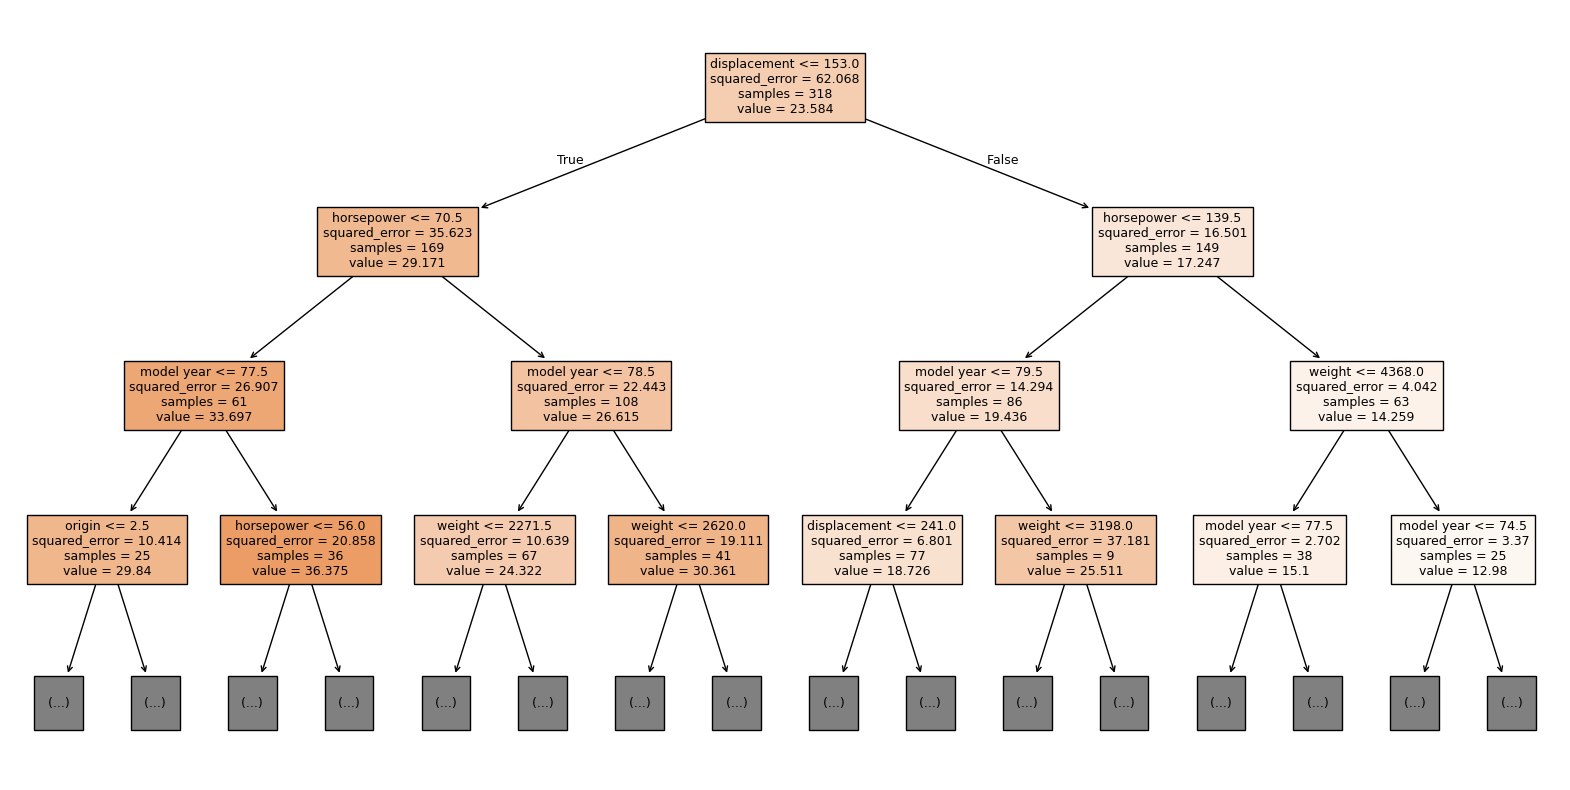

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    grid_search.best_estimator_,
    filled=True,
    feature_names=X.columns,
    fontsize=9,
    max_depth=3,
    )

plt.show();

Y la importancia relativa de cada característica del modelo:

In [ ]:
df_features = pd.DataFrame({'Feature': X.columns, 'Importance': grid_search.best_estimator_.feature_importances_})
df_features.sort_values('Importance', ascending=False)

,Feature,Importance
1,displacement,0.629007
2,horsepower,0.183234
5,model year,0.116877
3,weight,0.057832
4,acceleration,0.007678
6,origin,0.005373
0,cylinders,0.000000


# Modelos bagging

La primera pregunta que surge es ¿que sentido tiene entrenar muchos árboles con los mismos datos? En realidad, entrenar muchos estimadores del mismo tipo con el mismo conjunto de datos, conducirá a tener modelos muy similares, y el problema del sobreajuste no se solucionará. En realidad, lo ideal sería tener *un conjunto de datos diferente* para entrenar cada árbol.

¿Cómo conseguimos tener muchos conjuntos de datos diferentes? Usando técnicas de *remuestreo*.

La técnica de remuestreo más utilizada es el *bootstrap*, que consiste en hacer un nuevo dataset del mismo tamaño que conjunto de datos original, eligiendo al azar observaciones de este *una por una*, reemplazando las observaciones que van siendo elegidas. Esto significa que algunas observaciones pueden ser elegidas más de una vez, y algunos pueden no ser elegidas en absoluto. La gráfica siguiente lo ilustra:

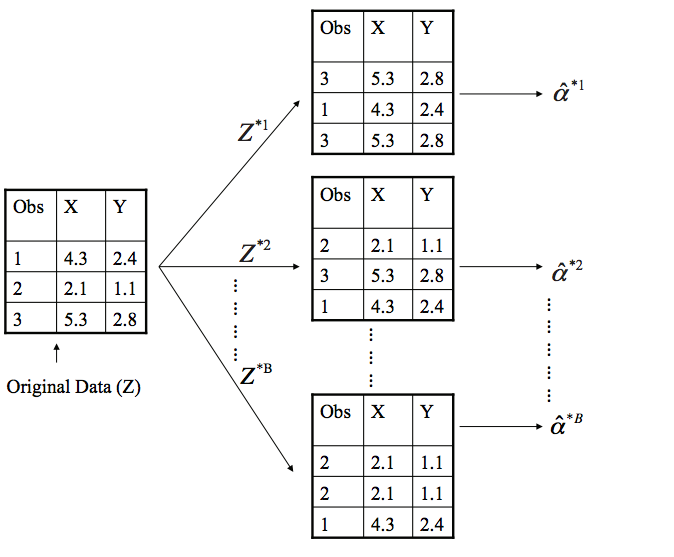

De esta manera, podemos entrenar cada estimador *de manera independiente*, y en paralelo si tenemos varios procesadores.

La siguiente pregunta que surge es ¿cómo se hace una predicción única si todos los estimadores pueden hacer predicciones diferentes?

En modelos de regresión la predicción es el valor promedio de las predicciones de los estimadores, y en clasificación, la predicción es la clase que más frecuentemente ha sido predicha por los estimadores.

Un modelo que funciona así se llama modelo de *Bagging*, y vamos a ver como se implementa.

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import root_mean_squared_error

bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=1),
    n_estimators=20,
    random_state=1
    )

bag_model.fit(X_train, y_train)

train_score = root_mean_squared_error(y_train, bag_model.predict(X_train))
test_score = root_mean_squared_error(y_test, bag_model.predict(X_test))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 2.785
Test score: 2.368


Este modelo está levemente sobreajustado. Podría intentarse mejorarlo sintonizando el número de estimadores a usar.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators':range(1, 201),
    }

random_search = RandomizedSearchCV(
    estimator=bag_model,
    param_distributions=param_distributions,
    scoring='neg_root_mean_squared_error',
    n_iter=20,
    random_state=2
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {-random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {-random_search.score(X_train, y_train):.3f}')
print(f'Test score: {-random_search.score(X_test, y_test):.3f}')

Best validation score: 3.254 with parameters: {'n_estimators': 4}
Train score: 2.806
Test score: 2.381


Un modelo de bagging es un modelo de **caja negra**. Un modelo de caja negra (*black-box model*) es un modelo cuyo funcionamiento interno no es fácilmente comprensible para las personas. Es decir, sabemos qué entra (datos) y qué sale (resultado), pero no está claro cómo el modelo tomó esa decisión.

# Random Forest

Hacer bootstrapping soluciona el problema de tener muchos datasets. Sin embargo, los datasets generados, al provenir de un único dataset, tienen similaridades entre sí, es decir que no son independientes, y esta condición es deseable para minimizar el *sesgo* que puedan tener los árboles.

Una posible solución, al menos parcialmente, es entrenar cada estimador con *características diferentes*. Esto es lo que hacen los modelos de bosques alaetorios - *Random Forest*.

Un *bosque aleatorio* es un modelo de ensamble formado por muchos árboles de decisión, donde cada uno de ellos es entrenado con un conjunto de datos diferentes generado por la técnica de *bootstrapping*; adicionalmente, para lograr una mayor diversidad de los estimadores, en cada nodo del árbol se selecciona aleatoriamente un subconjunto de características, de las cuales se escogerá la siguiente a usar para particionar el árbol.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    max_depth=3,
    n_estimators=20,
    random_state=1,
    )

rf_model.fit(X_train, y_train)

train_score = root_mean_squared_error(y_train, rf_model.predict(X_train))
test_score = root_mean_squared_error(y_test, rf_model.predict(X_test))
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 2.785
Test score: 2.366


Para regularizar un bosque aleatorio y evitar que se sobreajuste existen varios hiperparámetros que se pueden sintonizar; entre estos están:
1. n_estimators: Este hiperparámetro controla la cantidad de árboles de decisión dentro del bosque. Aunque se podría pensar que usar muchos árboles para ajustar un modelo ayudan a obtener un resultado más generalizable, esto no siempre es así. Aunque no causan ningún sobreajuste, aumentan la complejidad temporal del modelo.
2. max_depth: Este hiperparámetro rige la profundidad máxima hasta la que pueden crecer los árboles dentro del bosque. A medida que aumentamos la profundidad del árbol, la precisión del modelo aumenta hasta cierto límite, pero luego comenzará a disminuir gradualmente debido al sobreajuste en el modelo.
3. min_samples_split: Este hiperparámetro especifica la cantidad mínima de muestras que debe tener un nodo interno para dividirse en más nodos. Si tenemos un valor muy bajo de min_samples_splits, entonces, en este caso, el árbol continuará creciendo y comenzará a sobreajustarse.
4. max_features: Este hiperparámetro determina la cantidad de características que se deben considerar al buscar la mejor división. Se puede establecer como un número entero, flotante, string o None. Si es un entero, entonces considera ese número de características en cada división. Si es flotante, entonces muestra un porcentaje y las características $int(max_features * n_features)$ son consideradas en cada división. Si es "sqrt", entonces en cada división son consideradas únicamente la raíz cuadrada del total de características. Si es "log2", entonces solo las $log2(n_features)$ del total de características son consideradas en cada división. Si None, entonces todas las características son consideradas en cada división.
4. min_samples_leaf: Este hiperparámetro especifica el número mínimo de muestras que se deben tener en un nodo hoja. Un punto de división en cualquier profundidad solo se considerará si deja al menos min_samples_leaf muestras de entrenamiento en cada una de las ramas izquierda y derecha.
5. ccp_alpha: es un parámetro que se utiliza en un algoritmo de podado en los árboles de decisión, basado en la relación entre costo y complejidad. Un valor más alto de ccp_alpha resultará en árboles más pequeños y un modelo más simple, mientras que un valor más bajo permitirá que los árboles crezcan más y resultará en un modelo más complejo.

Se va a entrenar un bosque aleatorio sintonizando algunos de estos hiperparámetros:

In [ ]:
from scipy.stats import loguniform, uniform

dist = {
    'n_estimators':range(1, 201),
    'ccp_alpha':loguniform(1e-4, 1e2),
    'max_features':[4,5,6]
    }

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=dist,
    random_state=1,
    scoring='neg_root_mean_squared_error',
    n_iter=20
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {-random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {-random_search.score(X_train, y_train):.3f}')
print(f'Test score: {-random_search.score(X_test, y_test):.3f}')

Best validation score: 3.264 with parameters: {'ccp_alpha': np.float64(0.0026093591654417357), 'max_features': 5, 'n_estimators': 72}
Train score: 2.805
Test score: 2.342


Un bosque aleatorio también es un modelo de **caja negra**. Pero al menos, en estos tenemos el atributo *features_importances_*, que, como su nombre lo indica, entrega la importancia de cada característica computada mediante el algoritmo de Gini.

In [ ]:
rf_features = pd.DataFrame({'Feature': X.columns, 'Importance': random_search.best_estimator_.feature_importances_})
rf_features.sort_values('Importance', ascending=False)

,Feature,Importance
1,displacement,0.378937
3,weight,0.258199
0,cylinders,0.135138
5,model year,0.129778
2,horsepower,0.095863
4,acceleration,0.001641
6,origin,0.000444
